## Import libraries

In [40]:
import sys
from pathlib import Path
import warnings

sys.path.insert(0, "../scripts")
from clock_utils import (
    build_cluster_X,
    build_thompson_cluster_features,
    build_thompson_cpg_features,
    nested_cv,
    plot_age_clock,
)
from segmentation_utils import cluster_chroms, cluster_summary, segment_by_chromhmm

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, root_mean_squared_error


## Output Directories & Configuration

In [41]:
warnings.filterwarnings("ignore") # Ignore warnings for cleaner output, disable if you want to see them

output_dir = Path("../outputs/01_petkovich_blood_clocks")
plots_dir = output_dir / "plots"
output_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

colors = dict(
    cpg="steelblue",
    dbs="tomato",
    hdbscan="#006d2c",
    hdbscan_5="#74c476",
    hdbscan_10="#31a354",
    optics="mediumpurple",
)
labels_map = dict(
    cpg="CpG",
    dbs="DBSCAN",
    hdbscan="HDBSCAN mcs=20",
    hdbscan_5="HDBSCAN mcs=5",
    hdbscan_10="HDBSCAN mcs=10",
    optics="OPTICS",
)

# Training and testing Petkovich cluster-based and CpG-based clocks on the Petkovich dataset

## Preprocessing of the data

Preprocessing of both Petkovich and Thompson data was performed by Evgeniy Efimov. During the preprocesing step, all the methylation sites that had coverage <= 5 reads were handled as NaN.

## Load data

For some reason, `GSE80672_metlevs_processed.parquet.gz` does not contain some of the samples from the original GEO ('GSM2132821', 'GSM2132831', 'GSM2132846', 'GSM2132859', 'GSM2132894', 'GSM2132941', 'GSM2132943', 'GSM2132951', 'GSM2132959')

In [42]:
# Read Petkovich et al. (2017) methylation levels and metadata
parquet_cols = set(
    pq.read_schema(
        "../sources/Petkovich_GSE80672_Efi_processed/GSE80672_metlevs_processed.parquet.gz"
    ).names
)

petkovich_meta = (
    pd.read_csv(
        "../sources/Petkovich_GSE80672_Efi_processed/GSE80672_metadata_cleaned.csv"
    )
    .query("ID.str.match(r'^M(?!I)')")
    .rename(columns={"Unnamed: 0": "GSE"})
    .reset_index(drop=True)
)

valid_ids = [gse for gse in petkovich_meta["GSE"] if gse in parquet_cols]

petkovich_meta = petkovich_meta[petkovich_meta["GSE"].isin(valid_ids)].reset_index(
    drop=True
)
petkovich = pd.read_parquet(
    "../sources/Petkovich_GSE80672_Efi_processed/GSE80672_metlevs_processed.parquet.gz",
    columns=valid_ids,
)


## Use various density-based methods to cluster methylation sites

### Parse site coordinates

In [43]:
# Divide site index into chromosome and position
site_coords = pd.DataFrame(
    {
        "chrom": petkovich.index.str.rsplit("_", n=1).str[0],
        "pos": petkovich.index.str.rsplit("_", n=1).str[1].astype(int),
    },
    index=petkovich.index,
)

# Pre-compute chromosome groups once — reused for all three clustering methods
groups = list(site_coords.groupby("chrom"))

# y is defined early so HP search cells can use it without running feature matrices first
y = petkovich_meta.set_index("GSE")["Age"].loc[petkovich.columns].astype(float)

### Cluster CpS using DBSCAN

I did not search for hyperparameters for DBSCAN, since it was already performed by Simpson et. el. (2023)


DBSCAN eps=1000
Clusters:          57,065
Noise CpGs:       172,402  (14.5%)
Clustered CpGs: 1,020,649  (85.5%)

CpGs per cluster:
  mean:       17.9
  median:      9.0
  std:        24.0
  min:           5
  p25:           6
  p75:          17
  p90:          45
  p99:         122
  max:         589


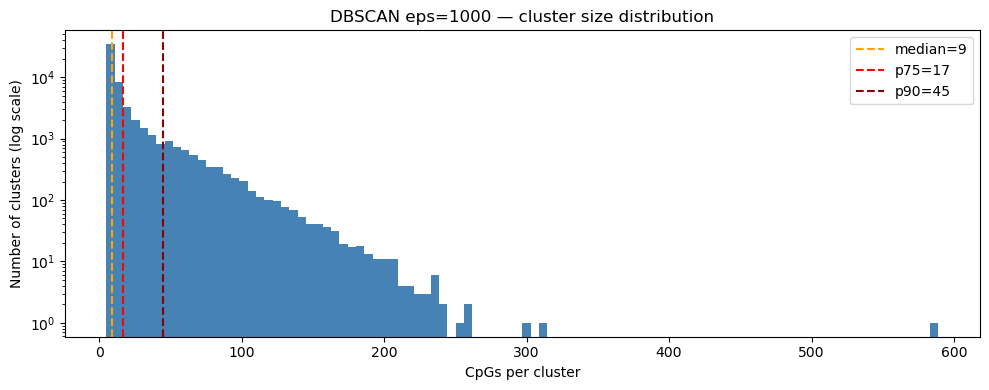

In [44]:
# eps = maximum distance in bp between neighboring CpGs to be in the same cluster (as in the original paper)
# min_samples = the number of samples (or total weight) in a neighborhood for a point to be considered as a core point (as in the original paper)

site_coords["cluster_dbs"] = cluster_chroms(
    groups, site_coords.index, DBSCAN, dict(eps=1000, min_samples=5)
)
cluster_summary(site_coords["cluster_dbs"], name="DBSCAN eps=1000", plot_dir=plots_dir)

### Cluster CpS using HDBSCAN with different hyperparameters and perform nested cross-validation 

#### Important note on the LASSO regression for age prediction

Apparently, in the Simpson et al. (2023) paper, they didn't use **nested cross-validation** for testing the performance of their model on the training data (Petkovich dataset in our case). They just used a single train-test split. I will implement nested cross-validation, which is a more robust and will allow us to compare the performance of CpG-based and cluster-based models more reliably.

#### Important note on the HDBSCAN hyperparameters

`min_samples` was kept equal to `min_cluster_size` (default behaviour of HDBSCAN implementation in sklearn).

#### Important note on the NaN handling

Here and for OPTICS, I used the same approach for NaN handling as described in `build_cluster_X` function docstring (see `scripts/clock_utils.py`)

In [45]:
# HDBSCAN hyperparameter search — min_cluster_size ∈ {3, 5, 10, 15, 20, 25, 30}
# Takes some time to run

# hdbscan_hp = {}

# for mcs in [3, 5, 10, 15, 20, 25, 30]:
#     labels = cluster_chroms(
#         groups,
#         site_coords.index,
#         HDBSCAN,
#         dict(
#             min_cluster_size=mcs,
#             min_samples=mcs,
#             copy=True,
#             cluster_selection_method="eom",
#         ),
#     )
#     in_cluster = labels[labels != -1]
#     X = petkovich.loc[in_cluster.index].groupby(in_cluster).mean(skipna=True)
#     row_means = X.mean(axis=1)
#     X = X.where(X.notna(), row_means, axis=0).dropna(axis=0).T
#     res = nested_cv(X, y)
#     hdbscan_hp[mcs] = {**res, "n_clusters": X.shape[1]}
#     print(
#         f"mcs={mcs:3d}: R²={res['R2 (OOF)']:.3f}, RMSE={res['RMSE (OOF)']:.2f}, "
#         f"clusters={X.shape[1]:6d}"
#     )

In [46]:
# # Save HDBSCAN HP search results
# with open(f"{output_dir}/petkovich_on_petkovich_hdbscan_hyperparams_search.pkl", "wb") as f:
#     pickle.dump(hdbscan_hp, f)

In [47]:
# Load best HDBSCAN results
with open(
    f"{output_dir}/petkovich_on_petkovich_hdbscan_hyperparams_search.pkl", "rb"
) as f:
    hdbscan_hp = pickle.load(f)

print(f"{'mcs':>5}  {'R²':>7}  {'RMSE':>7}  {'clusters':>10}")
print("-" * 38)
for mcs, res in sorted(hdbscan_hp.items()):
    print(
        f"{mcs:>5d}  {res['R2 (OOF)']:>7.3f}  {res['RMSE (OOF)']:>7.2f}  {res['n_clusters']:>10d}"
    )

best_mcs = max(hdbscan_hp, key=lambda k: hdbscan_hp[k]["R2 (OOF)"])
print(
    f"\nBest min_cluster_size: {best_mcs}  (R²={hdbscan_hp[best_mcs]['R2 (OOF)']:.3f})"
)


  mcs       R²     RMSE    clusters
--------------------------------------
    3    0.931     2.71      203863
    5    0.938     2.58      104179
   10    0.938     2.56       48792
   15    0.943     2.45       30817
   20    0.956     2.16       22228
   25    0.953     2.25       17492
   30    0.953     2.23       14536

Best min_cluster_size: 20  (R²=0.956)


#### Plot & summarize HDBSCAN cluster size info

While HDBSCAN with mcs=20 shows the best performance on Petkovich, it results in overfitting, showing poor results on external dataset. Therefore, I will test HDBSCAN with mcs=5 and 10, which is closer to biologically meaningful cluster sizes, as **DNMT3A methylates 5–8 CpG sites per processive binding event on human promoters** [Holz-Schietinger et al., 2010](https://pmc.ncbi.nlm.nih.gov/articles/PMC2937940/).


HDBSCAN min_cluster_size=20
Clusters:          22,228
Noise CpGs:       187,521  (15.7%)
Clustered CpGs: 1,005,530  (84.3%)

CpGs per cluster:
  mean:       45.2
  median:     38.0
  std:        24.3
  min:          20
  p25:          27
  p75:          56
  p90:          77
  p99:         129
  max:         239


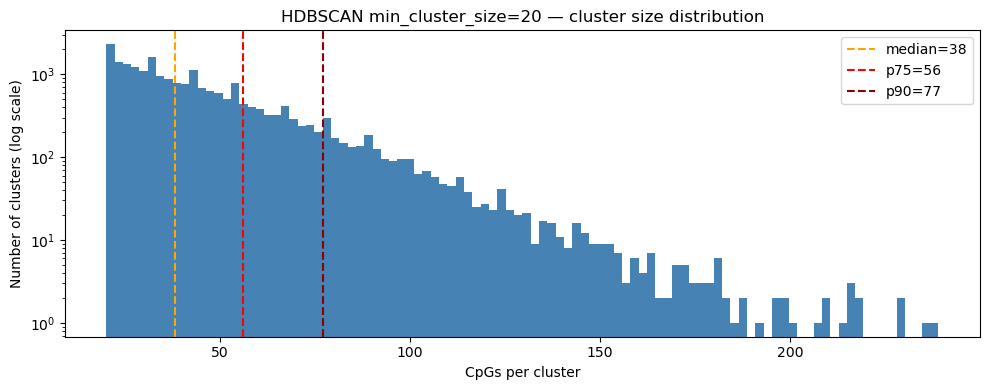

In [48]:
site_coords["cluster_hdbscan"] = cluster_chroms(
    groups,
    site_coords.index,
    HDBSCAN,
    dict(
        min_cluster_size=best_mcs,
        min_samples=best_mcs,
        copy=True,
        cluster_selection_method="eom",
    ),
)
cluster_summary(
    site_coords["cluster_hdbscan"],
    name=f"HDBSCAN min_cluster_size={best_mcs}",
    plot_dir=plots_dir,
)

for mcs in [5, 10]:
    site_coords[f"cluster_hdbscan_{mcs}"] = cluster_chroms(
        groups,
        site_coords.index,
        HDBSCAN,
        dict(min_cluster_size=mcs, min_samples=mcs, copy=True, cluster_selection_method="eom"),
    )

### Cluster CpS using OPTICS with different hyperparameters and perform nested cross-validation 

Since min_samples in OPTICS represents the same parameter as in DBSCAN, I will use the same value to make results somewhat comparable.

In [49]:
# # OPTICS hyperparameter search — xi ∈ {0.05, 0.1, 0.2, 0.25, 0.3}
# # xi ∈ (0, 1): minimum relative drop in reachability to define a cluster boundary. Smaller → more clusters.

# # Takes some time to run

# optics_hp = {}

# for xi in [0.05, 0.1, 0.2, 0.25, 0.3]:
#     labels = cluster_chroms(
#         groups,
#         site_coords.index,
#         OPTICS,
#         dict(max_eps=5000, min_samples=5, cluster_method="xi", xi=xi),
#     )
#     in_cluster = labels[labels != -1]
#     X = petkovich.loc[in_cluster.index].groupby(in_cluster).mean(skipna=True)
#     row_means = X.mean(axis=1)
#     X = X.where(X.notna(), row_means, axis=0).dropna(axis=0).T
#     res = nested_cv(X, y)
#     optics_hp[xi] = {**res, "n_clusters": X.shape[1]}
#     print(
#         f"xi={xi:.2f}: R²={res['R2 (OOF)']:.3f}, RMSE={res['RMSE (OOF)']:.2f}, "
#         f"clusters={X.shape[1]:6d}"
#     )


In [50]:
# # Save OPTICS HP search results
# with open(
#     f"{output_dir}/petkovich_on_petkovich_optics_hyperparams_search.pkl",
#     "wb",
# ) as f:
#     pickle.dump(optics_hp, f)

In [51]:
# Load best OPTICS results
with open(
    f"{output_dir}/petkovich_on_petkovich_optics_hyperparams_search.pkl", "rb"
) as f:
    optics_hp = pickle.load(f)

print(f"{'xi':>5}  {'R²':>7}  {'RMSE':>7}  {'clusters':>10}")
print("-" * 38)
for xi, res in sorted(optics_hp.items()):
    print(
        f"{xi:>5.2f}  {res['R2 (OOF)']:>7.3f}  {res['RMSE (OOF)']:>7.2f}  {res['n_clusters']:>10d}"
    )

best_xi = max(optics_hp, key=lambda k: optics_hp[k]["R2 (OOF)"])
print(f"\nBest xi: {best_xi:.2f}  (R²={optics_hp[best_xi]['R2 (OOF)']:.3f})")


   xi       R²     RMSE    clusters
--------------------------------------
 0.05    0.928     2.77      113337
 0.10    0.927     2.79      111405
 0.20    0.935     2.63      105488
 0.25    0.939     2.54      101554
 0.30    0.937     2.59       96281

Best xi: 0.25  (R²=0.939)


#### Plot & summarize OPTICS cluster size info


OPTICS xi=0.25
Clusters:         101,554
Noise CpGs:       330,982  (27.7%)
Clustered CpGs:   862,069  (72.3%)

CpGs per cluster:
  mean:        8.5
  median:      8.0
  std:         3.5
  min:           5
  p25:           6
  p75:          10
  p90:          13
  p99:          20
  max:          46


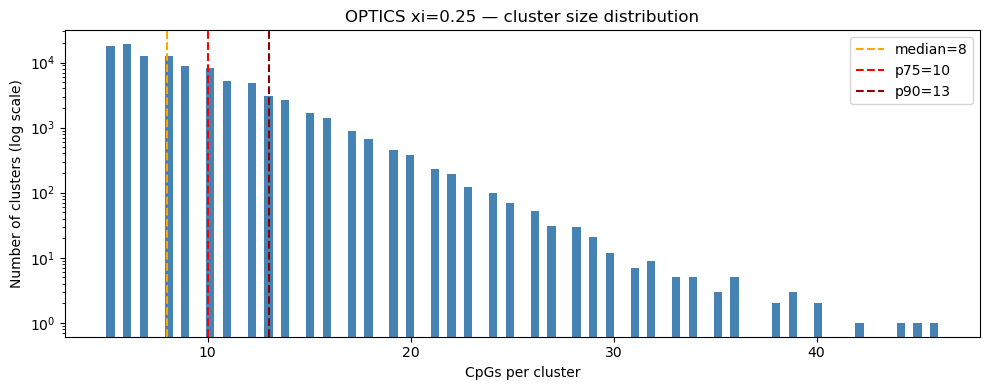

In [52]:
site_coords["cluster_optics"] = cluster_chroms(
    groups,
    site_coords.index,
    OPTICS,
    dict(max_eps=5000, min_samples=5, cluster_method="xi", xi=best_xi),
)
cluster_summary(
    site_coords["cluster_optics"], name=f"OPTICS xi={best_xi:.2f}", plot_dir=plots_dir
)


#### Plot OPTICS Reachability Plot

Reachability plot shows clear cluster structures (separated by high peaks) in 1D methylation data, further confirming the validity of the density-based approaches to cluster CpGs.

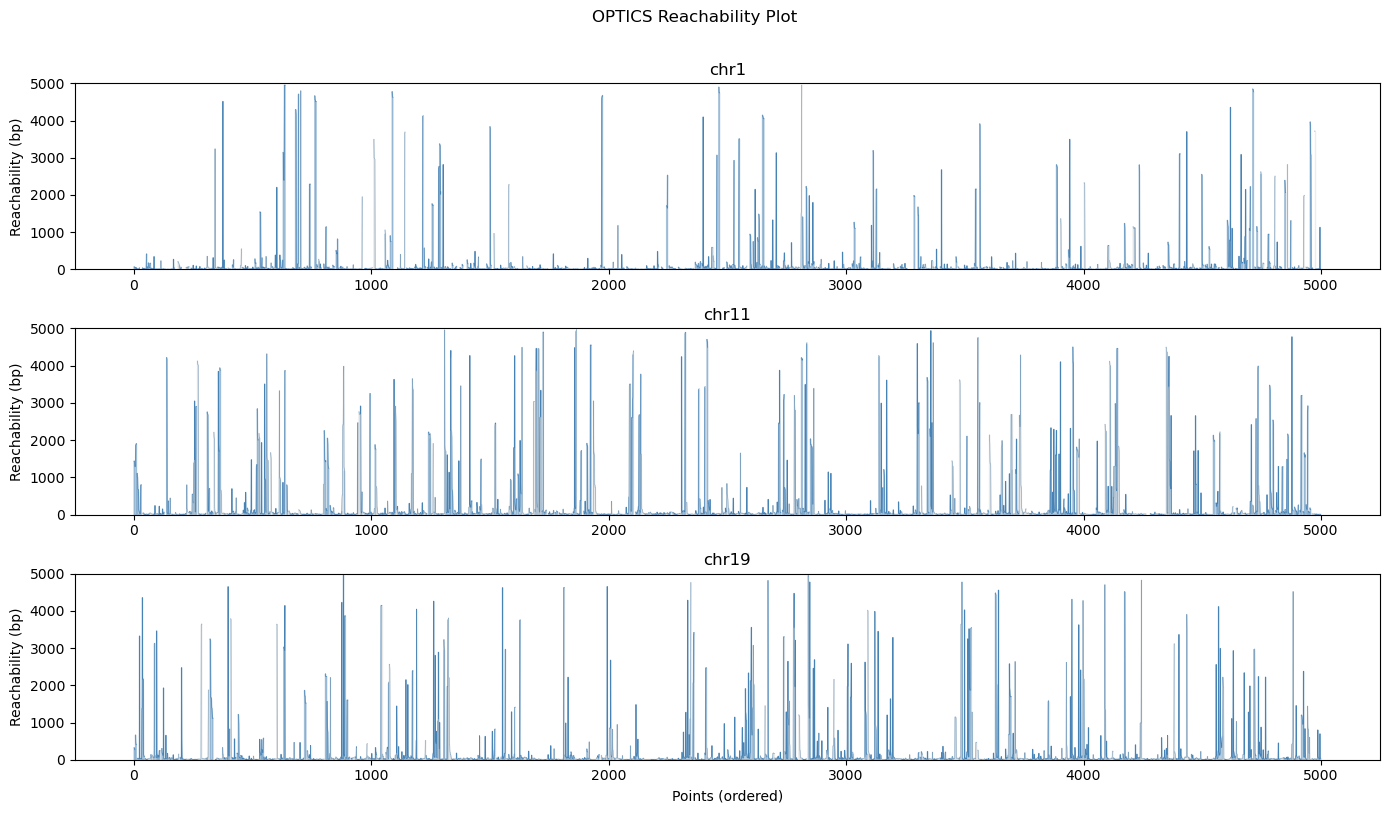

In [53]:
chroms = ["chr1", "chr11", "chr19"]
window = (0, 5000)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

for ax, chrom in zip(axes, chroms):
    coords = site_coords[site_coords["chrom"] == chrom]["pos"].values.reshape(-1, 1)

    optics = OPTICS(min_samples=5, max_eps=5000, cluster_method="xi", xi=best_xi)
    optics.fit(coords)

    reachability = optics.reachability_[optics.ordering_]
    labels = optics.labels_[optics.ordering_]

    r = reachability[window[0] : window[1]]
    l = labels[window[0] : window[1]]
    x = np.arange(len(r))

    ax.plot(x, r, lw=0.5, color="steelblue", zorder=1)

    ax.fill_between(x, r, where=(l != -1), color="steelblue", alpha=0.4, zorder=2)
    ax.fill_between(x, r, where=(l == -1), color="lightgray", alpha=0.4, zorder=2)

    ax.set_ylim(0, 5000)
    ax.set_ylabel("Reachability (bp)")
    ax.set_title(chrom)

axes[-1].set_xlabel("Points (ordered)")
plt.suptitle("OPTICS Reachability Plot", y=1.01)
plt.tight_layout()
plt.savefig(plots_dir / "optics_reachability.png", dpi=150, bbox_inches="tight")
plt.show()


## Nested cross-validation — internal testing (Petkovich)

Outer 5 folds evaluate R² and RMSE; inner 5 folds in LassoCV select alpha.

### Build feature matrices

In [54]:
petkovich_clean = petkovich.dropna(axis=0, how="any")
X_cpg = petkovich_clean.T
X_dbs = build_cluster_X(petkovich, site_coords, "cluster_dbs")
X_hdbscan    = build_cluster_X(petkovich, site_coords, "cluster_hdbscan")
X_hdbscan_5  = build_cluster_X(petkovich, site_coords, "cluster_hdbscan_5")
X_hdbscan_10 = build_cluster_X(petkovich, site_coords, "cluster_hdbscan_10")
X_optics = build_cluster_X(petkovich, site_coords, "cluster_optics")

print(f"CpG features: {X_cpg.shape[1]}, samples: {len(y)}")
print(f"DBSCAN: {X_dbs.shape[1]}, HDBSCAN mcs=5: {X_hdbscan_5.shape[1]}, mcs=10: {X_hdbscan_10.shape[1]}, mcs={best_mcs}: {X_hdbscan.shape[1]}")

CpG features: 912259, samples: 132
DBSCAN: 57065, HDBSCAN mcs=5: 104179, mcs=10: 48792, mcs=20: 22228


### Possible but skipped steps - Fitering features by correlation with age

In order for LASSO to run faster, one can prefilter the features by calculating the correlation between each feature and the target variable (age) and selecting only those features that have an absolute correlation above a certain threshold. This approach is based on the assumption that features that are not correlated with the target variable are unlikely to be useful for prediction. However, this approach could lead to the data leakage, since we are using the whole dataset to calculate the correlation. To avoid it, I decided not to use this step.

Note: this approach was not used in the Simpson et al. (2023) paper.

In [55]:
# # Correlation of each feature with age
# Xs = {"cpg": X_cpg, "dbs": X_dbs, "hdbscan": X_hdbscan, "optics": X_optics}
# cors = {name: X.corrwith(y) for name, X in Xs.items()}

# # Plot distributions
# fig, axes = plt.subplots(1, len(Xs), figsize=(5 * len(Xs), 4))
# for ax, (name, c) in zip(axes, cors.items()):
#     c.hist(ax=ax, bins=100, color=colors[name])
#     ax.set_title(f"{labels_map[name]}: {len(c)} features")
# plt.tight_layout()
# plt.show()

# # Count features above thresholds
# for name, c in cors.items():
#     for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
#         print(f"{labels_map[name]} |r| > {thr}: {(c.abs() > thr).sum()}")


### Back to the original pipeline - extracting results of nested cross-validation

In [56]:
# # Uncomment to run nested cross-validation for CpG-only and DBSCAN clustering-based features. 
# # HDBSCAN and OPTICS results are already available from the hyperparameter search 

# results_cpg = nested_cv(X_cpg, y)
# results_dbs = nested_cv(X_dbs, y)

# # Save results
# for name, res in [("cpg", results_cpg), ("dbs", results_dbs)]:
#     with open(
#         f"{output_dir}/petkovich_on_petkovich_{name}_nestedCV_results.pkl", "wb"
#     ) as f:
#         pickle.dump(res, f)


In [57]:
results = {}
for name in ["cpg", "dbs"]:
    with open(
        f"{output_dir}/petkovich_on_petkovich_{name}_nestedCV_results.pkl", "rb"
    ) as f:
        results[name] = pickle.load(f)

# Best HDBSCAN/OPTICS results come from the HP search cells above
results["hdbscan"] = hdbscan_hp[best_mcs]
results["optics"] = optics_hp[best_xi]

for name, res in results.items():
    print(
        f"{name:8s}: R²={res['R2 (OOF)']:.3f}, RMSE={res['RMSE (OOF)']:.2f}, "
        f"features={res['Avg Features']:.1f}"
    )


cpg     : R²=0.929, RMSE=2.53, features=105.2
dbs     : R²=0.950, RMSE=2.11, features=78.4
hdbscan : R²=0.956, RMSE=2.16, features=62.0
optics  : R²=0.939, RMSE=2.54, features=82.4


### Plot how well Petkovich clocks predict age in the internal testing (nested CV hold-outs)

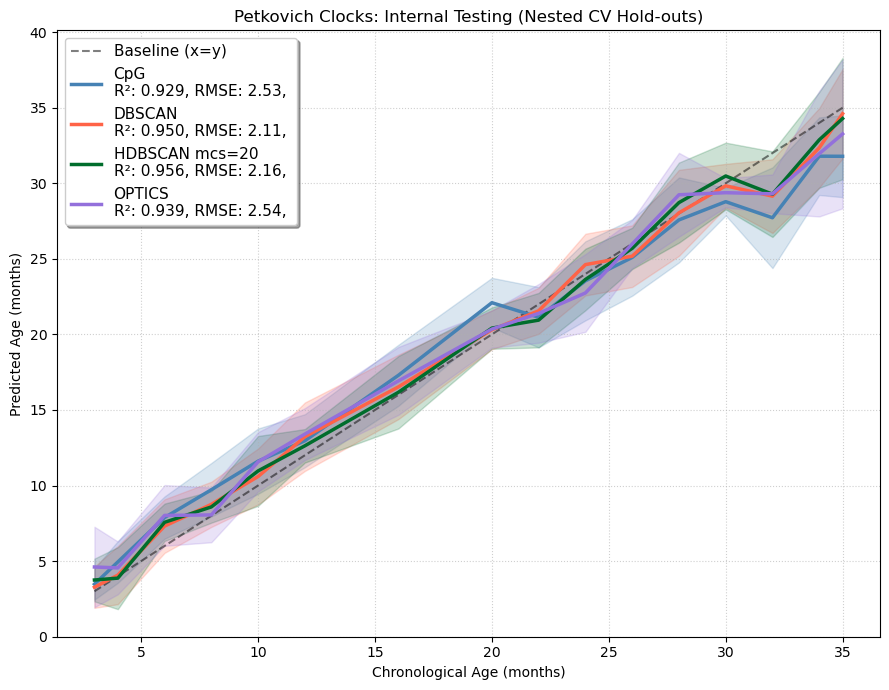

In [58]:
preds = [
    (
        results[name]["oof_pred"],
        (
            f"{labels_map[name]}\n"
            f"R²: {results[name]['R2 (OOF)']:.3f}, "
            f"RMSE: {results[name]['RMSE (OOF)']:.2f}, "
        ),
        colors[name],
    )
    for name in ["cpg", "dbs", "hdbscan", "optics"]
]

fig, ax = plt.subplots(figsize=(9, 7))
plot_age_clock(
    preds,
    y,
    "Petkovich Clocks: Internal Testing (Nested CV Hold-outs)",
    style="lines",
    ax=ax,
)
fig.savefig(
    plots_dir / "petkovich_on_petkovich_plot_lines.png", dpi=300, bbox_inches="tight"
)
plt.tight_layout()
plt.show()


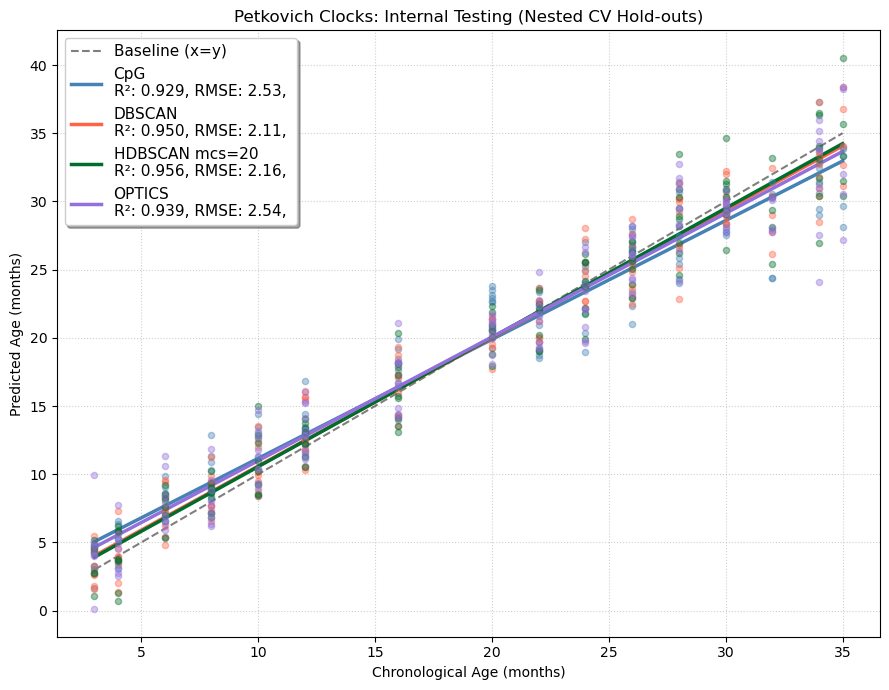

In [59]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_age_clock(
    preds,
    y,
    "Petkovich Clocks: Internal Testing (Nested CV Hold-outs)",
    style="scatter",
    ax=ax,
)
fig.savefig(plots_dir / "petkovich_on_petkovich_plot.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


## Train the final model that will be used for testing on external datasets
As the last step, we will train the final model on 100% of Petkovich data.

In [60]:
final_models = {}
for name, X in [
    ("cpg", X_cpg),
    ("dbs", X_dbs),
    ("hdbscan", X_hdbscan),
    ("hdbscan_5", X_hdbscan_5),
    ("hdbscan_10", X_hdbscan_10),
    ("optics", X_optics),
]:
    model = LassoCV(cv=5, max_iter=10000, n_jobs=-1, random_state=42).fit(X, y)
    final_models[name] = model
    print(f"{name:12s}: alpha={model.alpha_:.4f}, features={(model.coef_ != 0).sum()}")
    with open(f"{output_dir}/petkovich_{name}_full_model.pkl", "wb") as f:
        pickle.dump(model, f)

cpg         : alpha=0.0026, features=145
dbs         : alpha=0.0097, features=93
hdbscan     : alpha=0.0013, features=114
hdbscan_5   : alpha=0.0173, features=73
hdbscan_10  : alpha=0.0037, features=105
optics      : alpha=0.0028, features=127


# Testing Petkovich cluster-based and CpG-based clocks on the external Thompson dataset

## Load the data
Since we have trained our models on the blood methylation data from the Petkovich dataset, we will leverage only the blood methylation data from the Thompson dataset for testing. 

In [61]:
# Read Thompson et al. (2018) methylation levels and metadata (blood samples only)
parquet_cols = set(
    pq.read_schema(
        "../sources/Thompson_GSE120132_Efi_processed/GSE120132_metlevs_processed.parquet.gz"
    ).names
)

thompson_meta = (
    pd.read_csv(
        "../sources/Thompson_GSE120132_Efi_processed/GSE120132_metadata_cleaned.csv"
    )
    .query("Tissue == 'Blood'")
    .rename(columns={"Unnamed: 0": "GSE"})
    .reset_index(drop=True)
)

valid_ids = [gse for gse in thompson_meta["GSE"] if gse in parquet_cols]

thompson_meta = thompson_meta[thompson_meta["GSE"].isin(valid_ids)].reset_index(
    drop=True
)
thompson = pd.read_parquet(
    "../sources/Thompson_GSE120132_Efi_processed/GSE120132_metlevs_processed.parquet.gz",
    columns=valid_ids,
).T

In [62]:
X_thompson = {
    "cpg": build_thompson_cpg_features(thompson, X_cpg),
    "dbs": build_thompson_cluster_features(thompson, site_coords, "cluster_dbs", X_dbs),
    "hdbscan": build_thompson_cluster_features(
        thompson, site_coords, "cluster_hdbscan", X_hdbscan
    ),
    "hdbscan_5": build_thompson_cluster_features(
        thompson, site_coords, "cluster_hdbscan_5", X_hdbscan_5
    ),
    "hdbscan_10": build_thompson_cluster_features(
        thompson, site_coords, "cluster_hdbscan_10", X_hdbscan_10
    ),
    "optics": build_thompson_cluster_features(
        thompson, site_coords, "cluster_optics", X_optics
    ),
}

y_thompson = thompson_meta["Age"]

### Compare the performance of Petkovich clocks on the Thompson dataset (not stratified by sex)

cpg     : R²=0.628, RMSE=4.78
dbs     : R²=0.887, RMSE=2.63
hdbscan : R²=-1.253, RMSE=11.77
optics  : R²=-0.003, RMSE=7.85


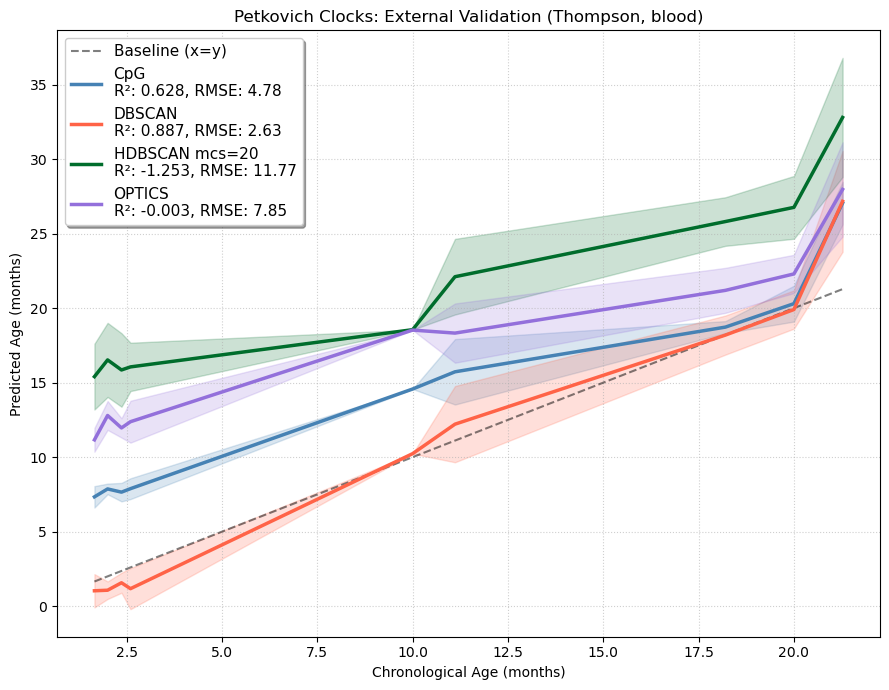

In [63]:
preds_ext = []
for name in ["cpg", "dbs", "hdbscan", "optics"]:
    pred = final_models[name].predict(X_thompson[name])
    r2 = r2_score(y_thompson, pred)
    rmse = root_mean_squared_error(y_thompson, pred)
    print(f"{name:8s}: R²={r2:.3f}, RMSE={rmse:.2f}")
    preds_ext.append(
        (
            pred,
            f"{labels_map[name]}\nR²: {r2:.3f}, RMSE: {rmse:.2f}",
            colors[name],
        )
    )

fig, ax = plt.subplots(figsize=(9, 7))
plot_age_clock(
    preds_ext,
    y_thompson,
    "Petkovich Clocks: External Validation (Thompson, blood)",
    style="lines",
    ax=ax,
)
fig.savefig(plots_dir / "thompson_validation_lines.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


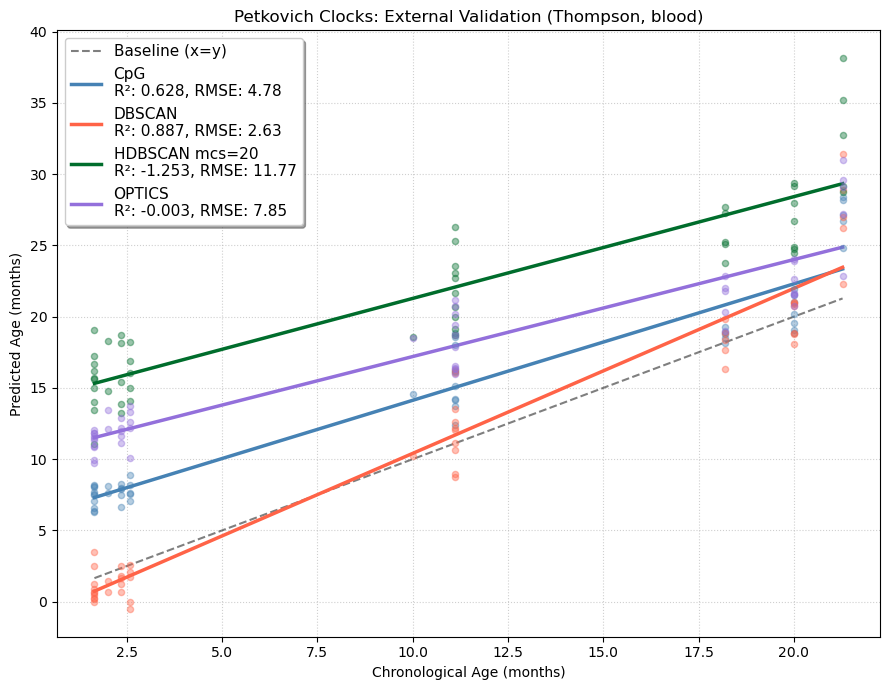

In [64]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_age_clock(
    preds_ext,
    y_thompson,
    "Petkovich Clocks: External Validation (Thompson, blood)",
    style="scatter",
    ax=ax,
)
fig.savefig(plots_dir / "thompson_validation.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


### Compare the performance of Petkovich clocks on the Thompson dataset stratified by sex

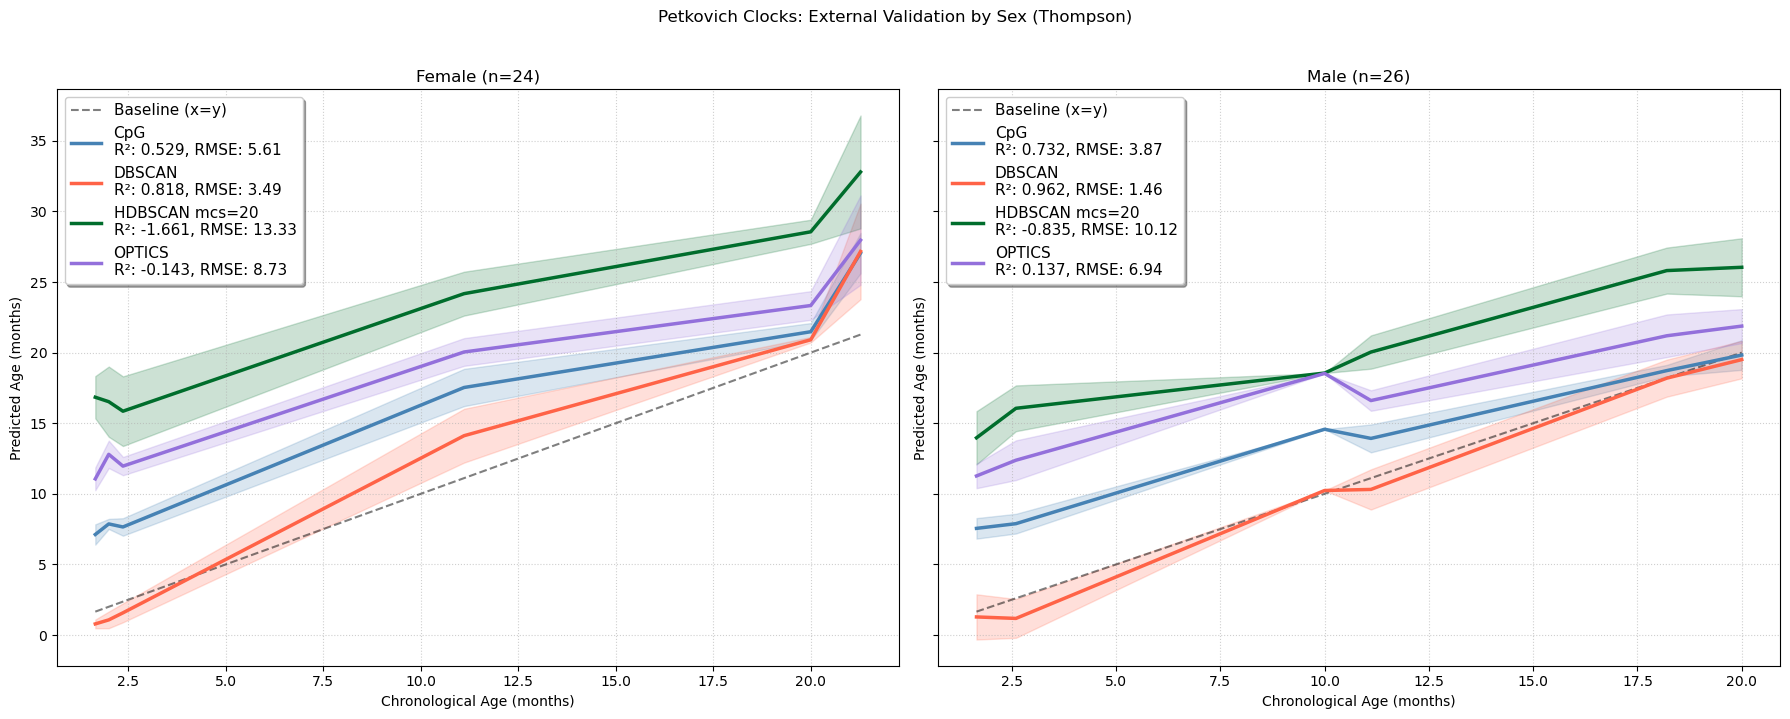

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, sex in zip(axes, ["Female", "Male"]):
    sex_idx = thompson_meta[thompson_meta["Sex"] == sex].index
    sex_pos = [thompson_meta.index.get_loc(i) for i in sex_idx]
    y_sex = thompson_meta.loc[sex_idx, "Age"]

    preds_sex = []
    for name in ["cpg", "dbs", "hdbscan", "optics"]:
        pred = final_models[name].predict(X_thompson[name][sex_pos])
        r2 = r2_score(y_sex, pred)
        rmse = root_mean_squared_error(y_sex, pred)
        lbl = f"{labels_map[name]}\nR²: {r2:.3f}, RMSE: {rmse:.2f}"
        preds_sex.append((pred, lbl, colors[name]))

    plot_age_clock(preds_sex, y_sex, f"{sex} (n={len(sex_idx)})", style="lines", ax=ax)

fig.suptitle("Petkovich Clocks: External Validation by Sex (Thompson)", y=1.02)
plt.tight_layout()
fig.savefig(plots_dir / "thompson_validation_by_sex_lines.png", dpi=300, bbox_inches="tight")
plt.show()


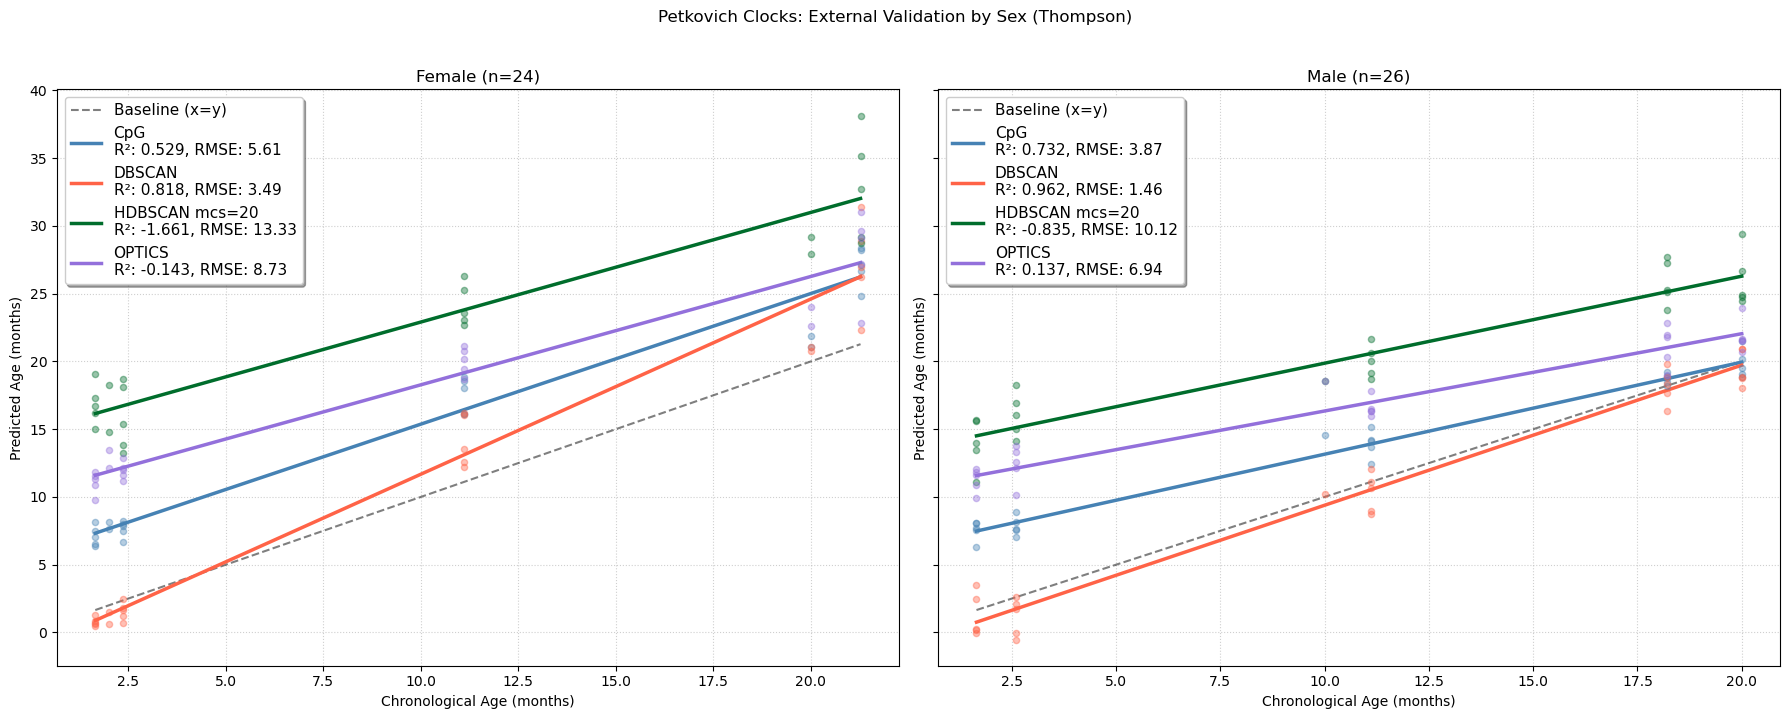

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, sex in zip(axes, ["Female", "Male"]):
    sex_idx = thompson_meta[thompson_meta["Sex"] == sex].index
    sex_pos = [thompson_meta.index.get_loc(i) for i in sex_idx]
    y_sex = thompson_meta.loc[sex_idx, "Age"]

    preds_sex = []
    for name in ["cpg", "dbs", "hdbscan", "optics"]:
        pred = final_models[name].predict(X_thompson[name][sex_pos])
        r2 = r2_score(y_sex, pred)
        rmse = root_mean_squared_error(y_sex, pred)
        lbl = f"{labels_map[name]}\nR²: {r2:.3f}, RMSE: {rmse:.2f}"
        preds_sex.append((pred, lbl, colors[name]))

    plot_age_clock(preds_sex, y_sex, f"{sex} (n={len(sex_idx)})", style="scatter", ax=ax)

fig.suptitle("Petkovich Clocks: External Validation by Sex (Thompson)", y=1.02)
plt.tight_layout()
fig.savefig(plots_dir / "thompson_validation_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()


## HDBSCAN min_cluster_size comparison: External Validation (Thompson)

**Why HDBSCAN (mcs=20) fails on Thompson while DBSCAN transfers well.**

The failure is a compound of two issues (analysis not shown here):

1. **Mean imputation turns missing features into a hard offset.** Only ~3.4% of HDBSCAN clusters are absent in Thompson (vs 13.5% for DBSCAN), but these features carry 15.5% of the total coefficients mass. When their values are imputed with the Petkovich training mean, the contribution becomes a constant rather than a age-specific signal — adding a fixed **+3.77 mo** to every Thompson prediction. The DBSCAN equivalent is −0.15 mo, essentially noise.

2. **LASSO selects weaker features in the HDBSCAN feature space.** HDBSCAN yields 22,228 candidate clusters from 132 samples; the selected features have median Pearson correlation with age of only 0.225 in Petkovich (0.254 in Thompson). DBSCAN selects features with median correlation ≈ 0.35 — a more stable biological signal.

The visible consequence on the predicted-vs-real plot: HDBSCAN predictions on Thompson never drop below 10 months, because the intercept plus the imputation offset (+3.77) creates a hard floor regardless of the true methylation profile.

**A note on hyperparameter selection.** OOF R² across mcs ∈ {3..30} ranges 0.931–0.956 — a spread of 0.025. Picking mcs=20 as "best of 7" on the same data was a selection bias, becuse the real difference is too small. The apparent Petkovich advantage of HDBSCAN is therefore an artifact of the selection procedure.

As shown below, reducing mcs to 5 (which results in smaller clusters) improves HDBSCAN-based clusters transferability to Thompson, but still does not outperform DBSCAN-based clusters. This is a subject for future investigation

dbs         : R²=0.887, RMSE=2.63
hdbscan_5   : R²=0.635, RMSE=4.74
hdbscan_10  : R²=-1.327, RMSE=11.96
hdbscan     : R²=-1.253, RMSE=11.77


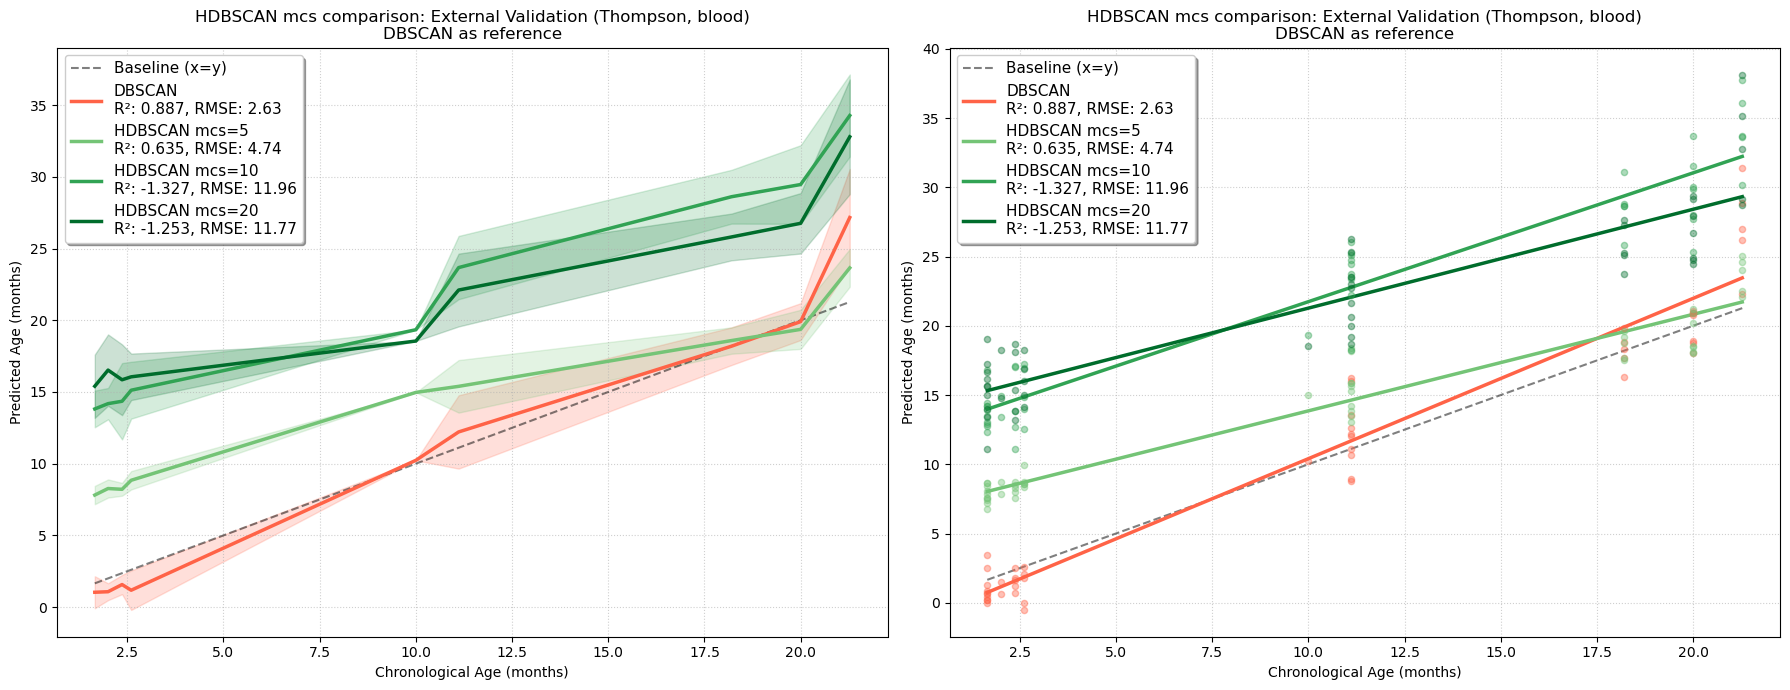

In [67]:
preds_hdb_cmp = []
for name in ["dbs", "hdbscan_5", "hdbscan_10", "hdbscan"]:
    pred = final_models[name].predict(X_thompson[name])
    r2   = r2_score(y_thompson, pred)
    rmse = root_mean_squared_error(y_thompson, pred)
    preds_hdb_cmp.append((pred, f"{labels_map[name]}\nR²: {r2:.3f}, RMSE: {rmse:.2f}", colors[name]))
    print(f"{name:12s}: R²={r2:.3f}, RMSE={rmse:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, style in zip(axes, ["lines", "scatter"]):
    plot_age_clock(
        preds_hdb_cmp,
        y_thompson,
        "HDBSCAN mcs comparison: External Validation (Thompson, blood)\nDBSCAN as reference",
        style=style,
        ax=ax,
    )
plt.tight_layout()
fig.savefig(plots_dir / "thompson_hdbscan_mcs_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ChromHMM-based segmentation

Mouse ChromHMM annotation is taken from Vu, H., Ernst, J. Universal chromatin state annotation of the mouse genome. Genome Biol 24, 153 (2023). https://doi.org/10.1186/s13059-023-02994-x, pan-tissue full-stack model (100 states). The annotation file was found on GitHub (https://github.com/ernstlab/mouse_fullStack_annotations) and downloaded from https://public.hoffman2.idre.ucla.edu/ernst/2K9RS//full_stack/full_stack_annotation_public_release/mm10/mm10_100_segments_segments.bed.gz on 15.05.2026.

In [68]:
CHROMHMM_BED_MOUSE = Path(
    "../sources/mouse_full_stack_ChromHMM_annotations/mm10_100_segments_segments.bed.gz"
)

colors["chromhmm"] = "#8856a7"
labels_map["chromhmm"] = "ChromHMM"


## Do the ChromHMM-based segmentation of Petkovich dataset

I will drop segments with <5 CpGs to avoid pseudo-aggregation. The reason for this is that 25% of ChromHMM-segments have 1 CpG and 46% have ≤2. Upon segmentation, those features behave as renamed CpGs, creating a false feeling of clustering. Threshold of 5 CpGs echoes the DNMT3A processivity argument used for HDBSCAN (see notes on HDBSCAN min_cluster_size values above).

In [69]:
X_chromhmm = segment_by_chromhmm(petkovich, CHROMHMM_BED_MOUSE, min_cpgs=5)
print(f"ChromHMM segments covered: {X_chromhmm.shape[1]:,}")

ChromHMM segments covered: 60,735


## Nested cross-validation on Petkovich dataset for ChromHMM-based features

In [70]:
results["chromhmm"] = nested_cv(X_chromhmm, y)
with open(f"{output_dir}/petkovich_on_petkovich_chromhmm_nestedCV_results.pkl", "wb") as f:
    pickle.dump(results["chromhmm"], f)

name = "chromhmm"
print(
    f"{name}: R²={results[name]['R2 (OOF)']:.3f}, "
    f"RMSE={results[name]['RMSE (OOF)']:.2f}, "
    f"features={results[name]['Avg Features']:.1f}"
)

chromhmm: R²=0.935, RMSE=2.63, features=61.4


### Plot the results of internal testing

Here, I will compare the performance of ChromHMM-based features with the original CpG-based model and DBSCAN-based model (as the best-performing density-based clustering method).

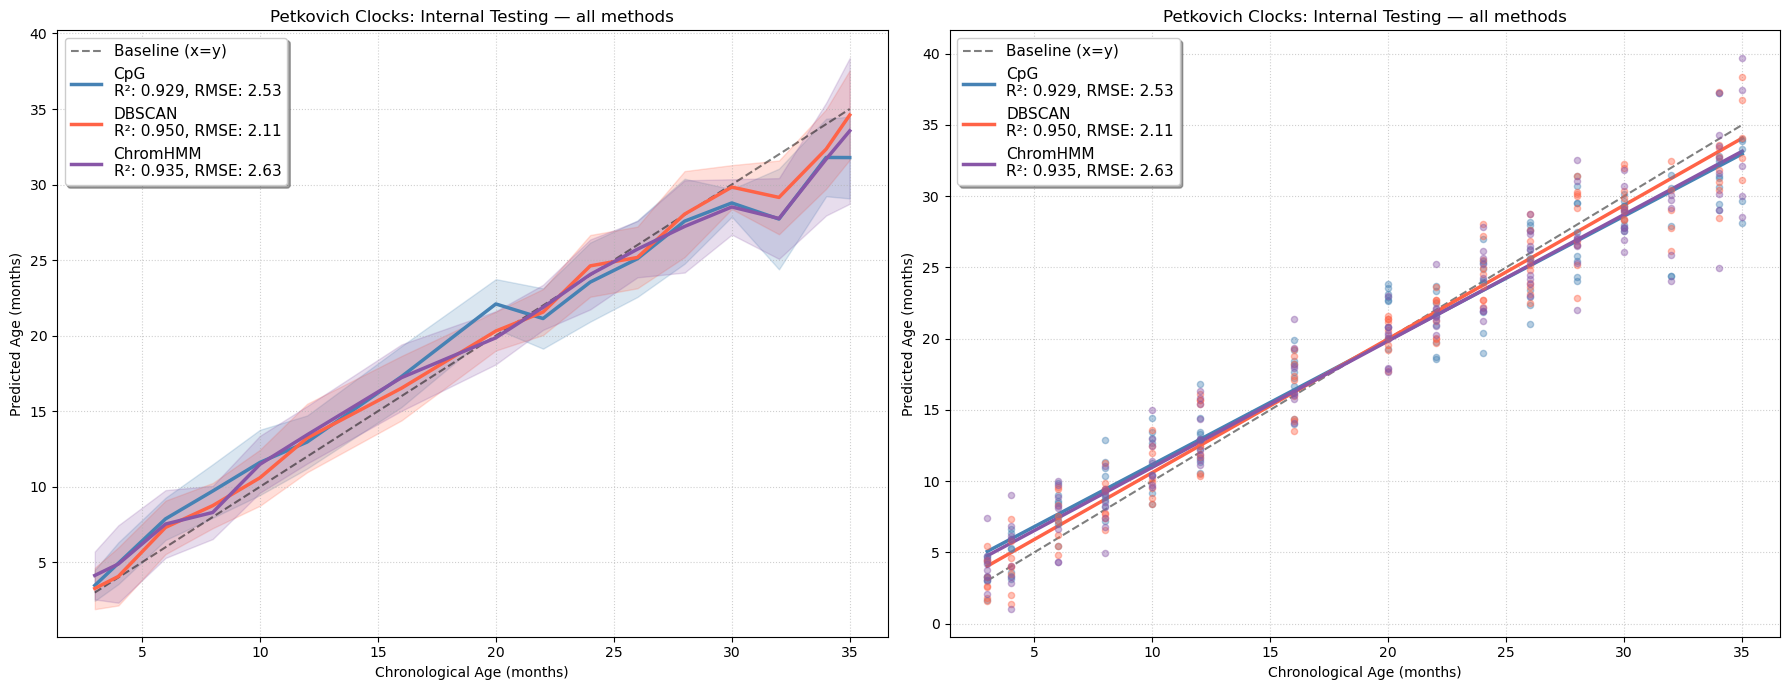

In [71]:
preds_internal = [
    (
        results[name]["oof_pred"],
        (
            f"{labels_map[name]}\n"
            f"R\u00b2: {results[name]['R2 (OOF)']:.3f}, "
            f"RMSE: {results[name]['RMSE (OOF)']:.2f}"
        ),
        colors[name],
    )
    for name in ["cpg", "dbs", "chromhmm"]
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, style in zip(axes, ["lines", "scatter"]):
    plot_age_clock(
        preds_internal, y,
        "Petkovich Clocks: Internal Testing \u2014 all methods",
        style=style, ax=ax,
    )
plt.tight_layout()
fig.savefig(plots_dir / "petkovich_on_petkovich_all_methods.png", dpi=300, bbox_inches="tight")
plt.show()

## Train final ChromHMM model on 100% of Petkovich data

In [72]:
model = LassoCV(cv=5, max_iter=10000, n_jobs=-1, random_state=42).fit(X_chromhmm, y)
final_models["chromhmm"] = model
print(f"chromhmm: alpha={model.alpha_:.4f}, features={(model.coef_ != 0).sum()}")
with open(f"{output_dir}/petkovich_chromhmm_full_model.pkl", "wb") as f:
    pickle.dump(model, f)

chromhmm: alpha=0.0091, features=105


## External validation on Thompson — ChromHMM

Here, I will use min_cpgs=1 so that segment_by_chromhmm is only used to filter CpGs by their presence in the ChromHMM annotation. Then, I will impute the missing features with the mean values from Petkovich dataset

In [73]:
# Aggregate Thompson CpGs into ChromHMM segments
X_t_chromhmm = segment_by_chromhmm(thompson.T, CHROMHMM_BED_MOUSE)

# Segments present in Petkovich but absent from Thompson become NaN columns
X_t_aligned = X_t_chromhmm.reindex(columns=X_chromhmm.columns)

# NaN imputation (mirrors build_thompson_cluster_features)
X_t_values = X_t_aligned.to_numpy(dtype=float)
thompson_segment_means  = np.nanmean(X_t_values, axis=0) # NaN where column is fully absent
petkovich_segment_means = X_chromhmm.mean().values

impute_values = np.where(
    np.isnan(thompson_segment_means),
    petkovich_segment_means,  # fully-absent segments (entire column is NaN): fall back to Petkovich train mean
    thompson_segment_means,  # partially-missing segments: fill with Thompson's own column mean.
)
nan_rows, nan_cols = np.where(np.isnan(X_t_values))
X_t_values[nan_rows, nan_cols] = impute_values[nan_cols]

X_thompson["chromhmm"] = X_t_values

### Plot the results of external testing

cpg       : R²=0.628, RMSE=4.78
dbs       : R²=0.887, RMSE=2.63
chromhmm  : R²=0.926, RMSE=2.13


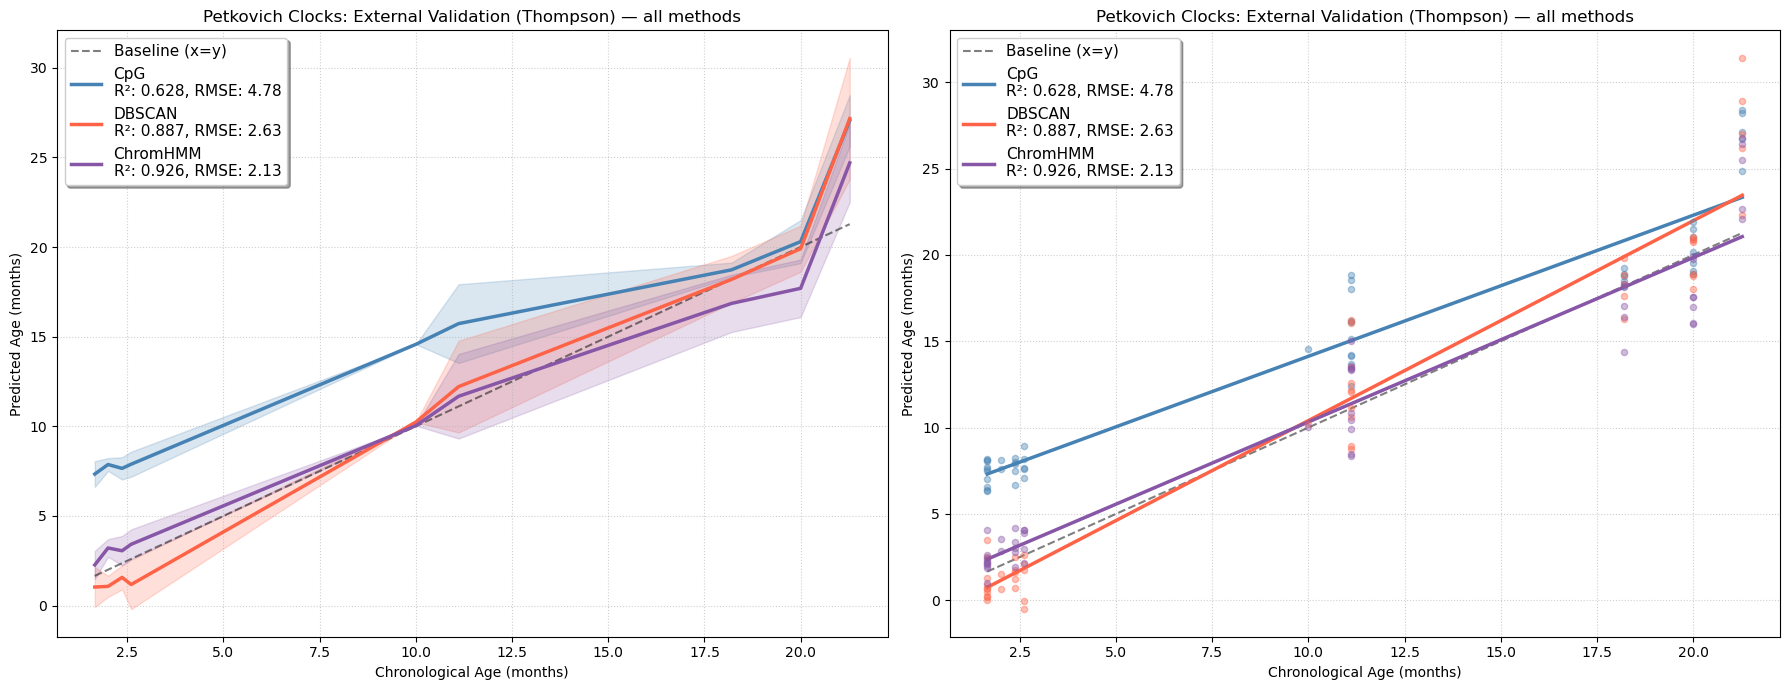

In [74]:
preds_all_ext = []
for name in ["cpg", "dbs", "chromhmm"]:
    pred = final_models[name].predict(X_thompson[name])
    r2   = r2_score(y_thompson, pred)
    rmse = root_mean_squared_error(y_thompson, pred)
    print(f"{name:10s}: R\u00b2={r2:.3f}, RMSE={rmse:.2f}")
    preds_all_ext.append(
        (pred, f"{labels_map[name]}\nR\u00b2: {r2:.3f}, RMSE: {rmse:.2f}", colors[name])
    )

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, style in zip(axes, ["lines", "scatter"]):
    plot_age_clock(
        preds_all_ext,
        y_thompson,
        "Petkovich Clocks: External Validation (Thompson) \u2014 all methods",
        style=style, ax=ax,
    )
plt.tight_layout()
fig.savefig(plots_dir / "thompson_validation_all_methods.png", dpi=300, bbox_inches="tight")
plt.show()

### Compare the performance of Petkovich ChromHMM clock on the Thompson dataset stratified by sex

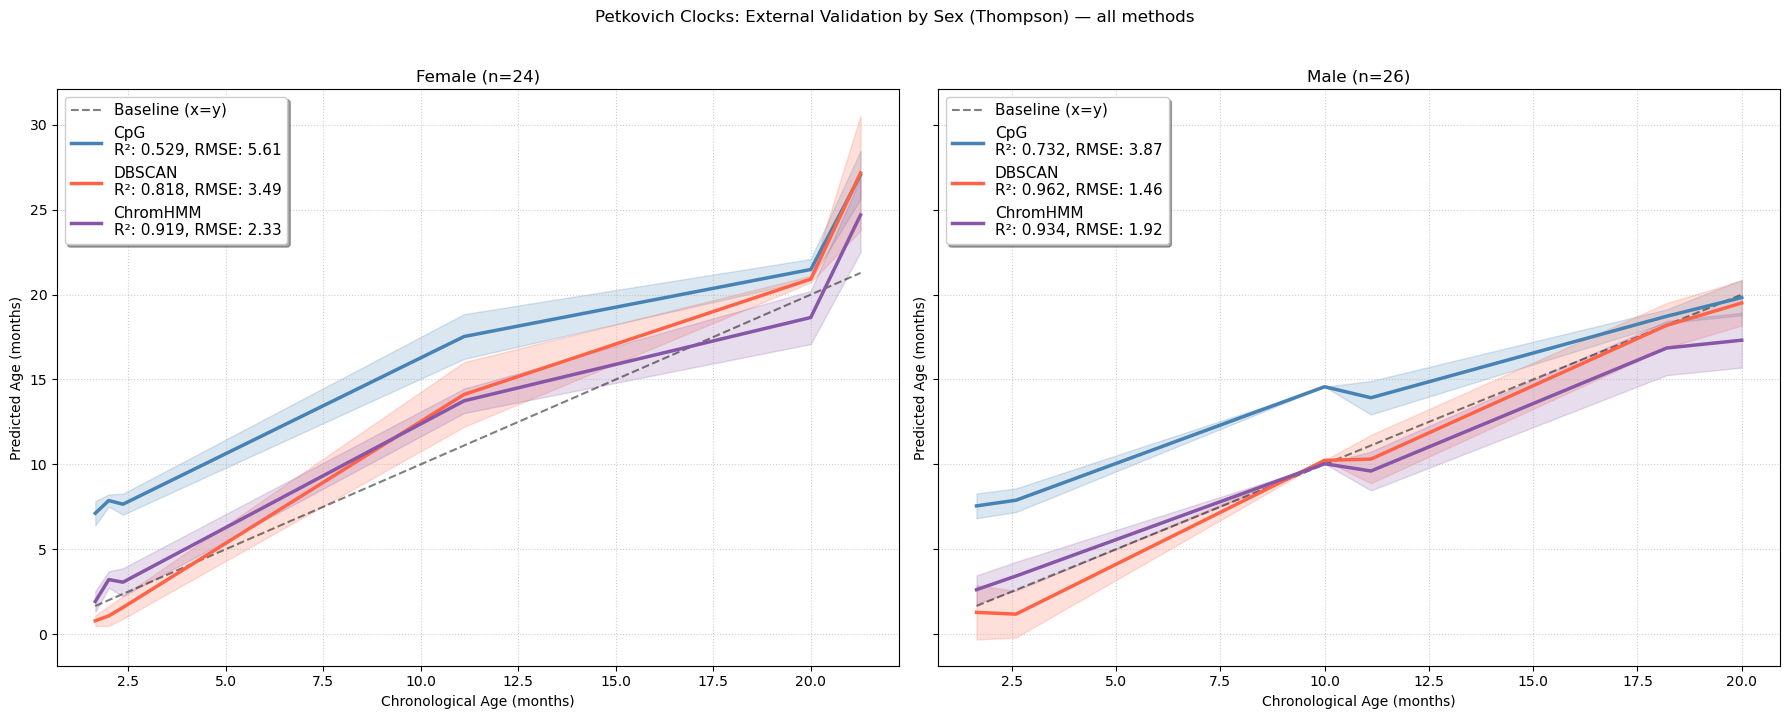

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, sex in zip(axes, ["Female", "Male"]):
    sex_idx = thompson_meta[thompson_meta["Sex"] == sex].index
    sex_pos = [thompson_meta.index.get_loc(i) for i in sex_idx]
    y_sex = thompson_meta.loc[sex_idx, "Age"]

    preds_sex = []
    for name in ["cpg", "dbs", "chromhmm"]:
        pred = final_models[name].predict(X_thompson[name][sex_pos])
        r2 = r2_score(y_sex, pred)
        rmse = root_mean_squared_error(y_sex, pred)
        preds_sex.append((pred, f"{labels_map[name]}\nR²: {r2:.3f}, RMSE: {rmse:.2f}", colors[name]))

    plot_age_clock(preds_sex, y_sex, f"{sex} (n={len(sex_idx)})", style="lines", ax=ax)

fig.suptitle("Petkovich Clocks: External Validation by Sex (Thompson) — all methods", y=1.02)
plt.tight_layout()
fig.savefig(plots_dir / "thompson_validation_by_sex_all_methods_lines.png", dpi=300, bbox_inches="tight")
plt.show()

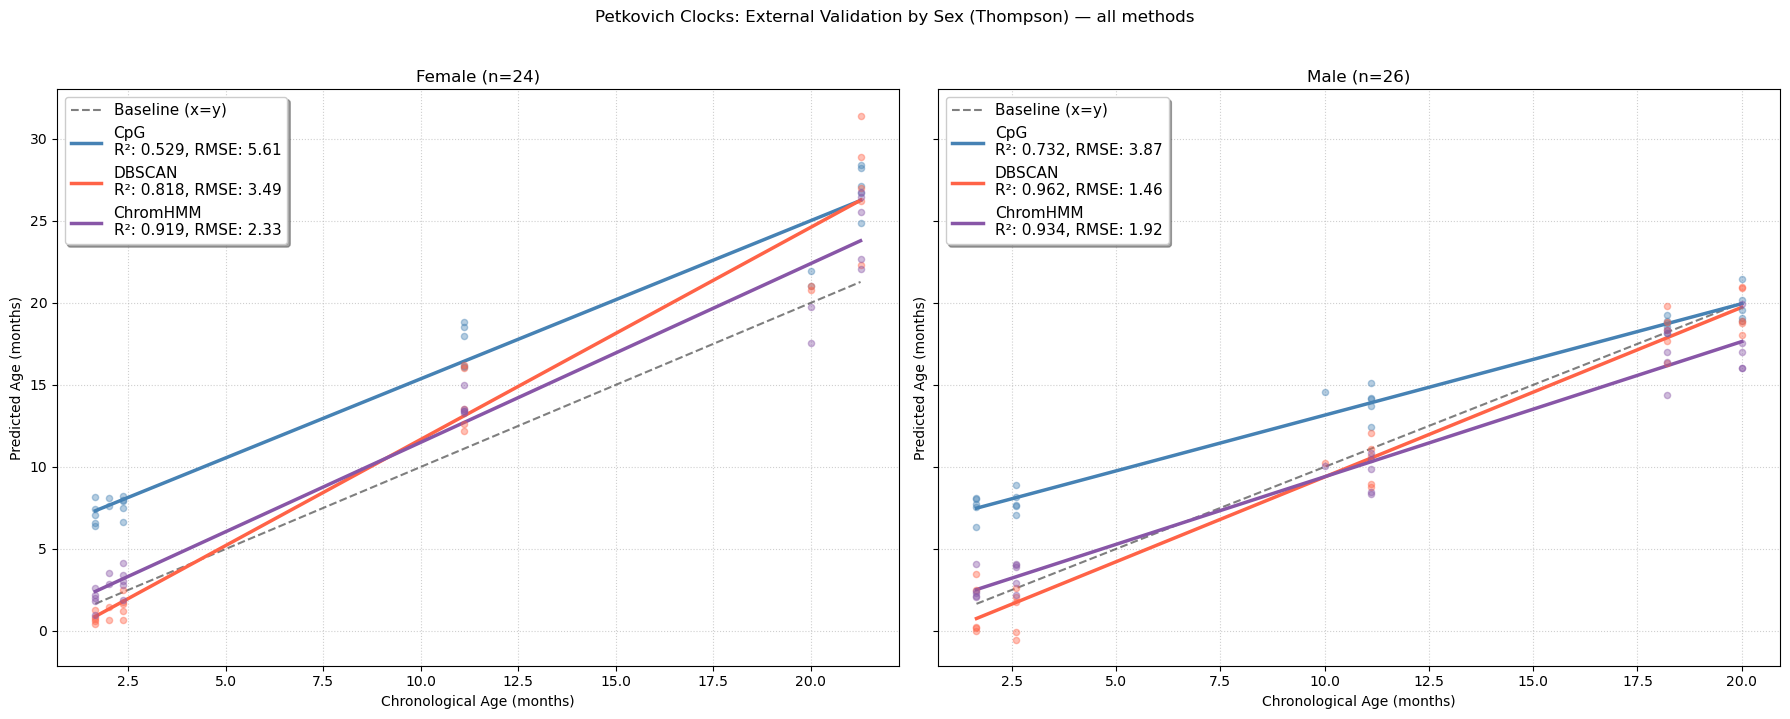

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, sex in zip(axes, ["Female", "Male"]):
    sex_idx = thompson_meta[thompson_meta["Sex"] == sex].index
    sex_pos = [thompson_meta.index.get_loc(i) for i in sex_idx]
    y_sex = thompson_meta.loc[sex_idx, "Age"]

    preds_sex = []
    for name in ["cpg", "dbs", "chromhmm"]:
        pred = final_models[name].predict(X_thompson[name][sex_pos])
        r2 = r2_score(y_sex, pred)
        rmse = root_mean_squared_error(y_sex, pred)
        preds_sex.append((pred, f"{labels_map[name]}\nR²: {r2:.3f}, RMSE: {rmse:.2f}", colors[name]))

    plot_age_clock(preds_sex, y_sex, f"{sex} (n={len(sex_idx)})", style="scatter", ax=ax)

fig.suptitle("Petkovich Clocks: External Validation by Sex (Thompson) — all methods", y=1.02)
plt.tight_layout()
fig.savefig(plots_dir / "thompson_validation_by_sex_all_methods.png", dpi=300, bbox_inches="tight")
plt.show()